# 1. 安装大模型模型

## 1.1 安装ollama

- （大模型）模型的使用（模型的使用能力：模型的实现，数据采集，数据集工程，训练，评估，评估，推理，量化：pytorch,transformers:机器学习，深度学习，强化学习）：
    - transformers 框架加载，推理（langchai）。
    - 使用第三方平台：把大模型发布为一个服务（HTTP/HTTPS协议）【开发模型平台】
            - 在langchain 中直接使用大模型【使用服务完成智能代理：龙虾，智能客户助手】


- 第三方平台分类：
    - 收费
    - 免费
        - （闭源）：免费/使用免费
        - （开源）： ！！！！

- 搭建本地大模型服务平台：(内存管理，进程管理，GPU管理，与底层系统的调用，驱动，Flash-Aten,各种模型的调用设计，**模型加载**，**服务接口**)
    - ollama(Windows/Linux)
    - vllm(Linux)
    - SGLang(Linux)
    - '[transformers]'

### （ 1）下载地址

- 直接官网拷贝：https://ollama.com/

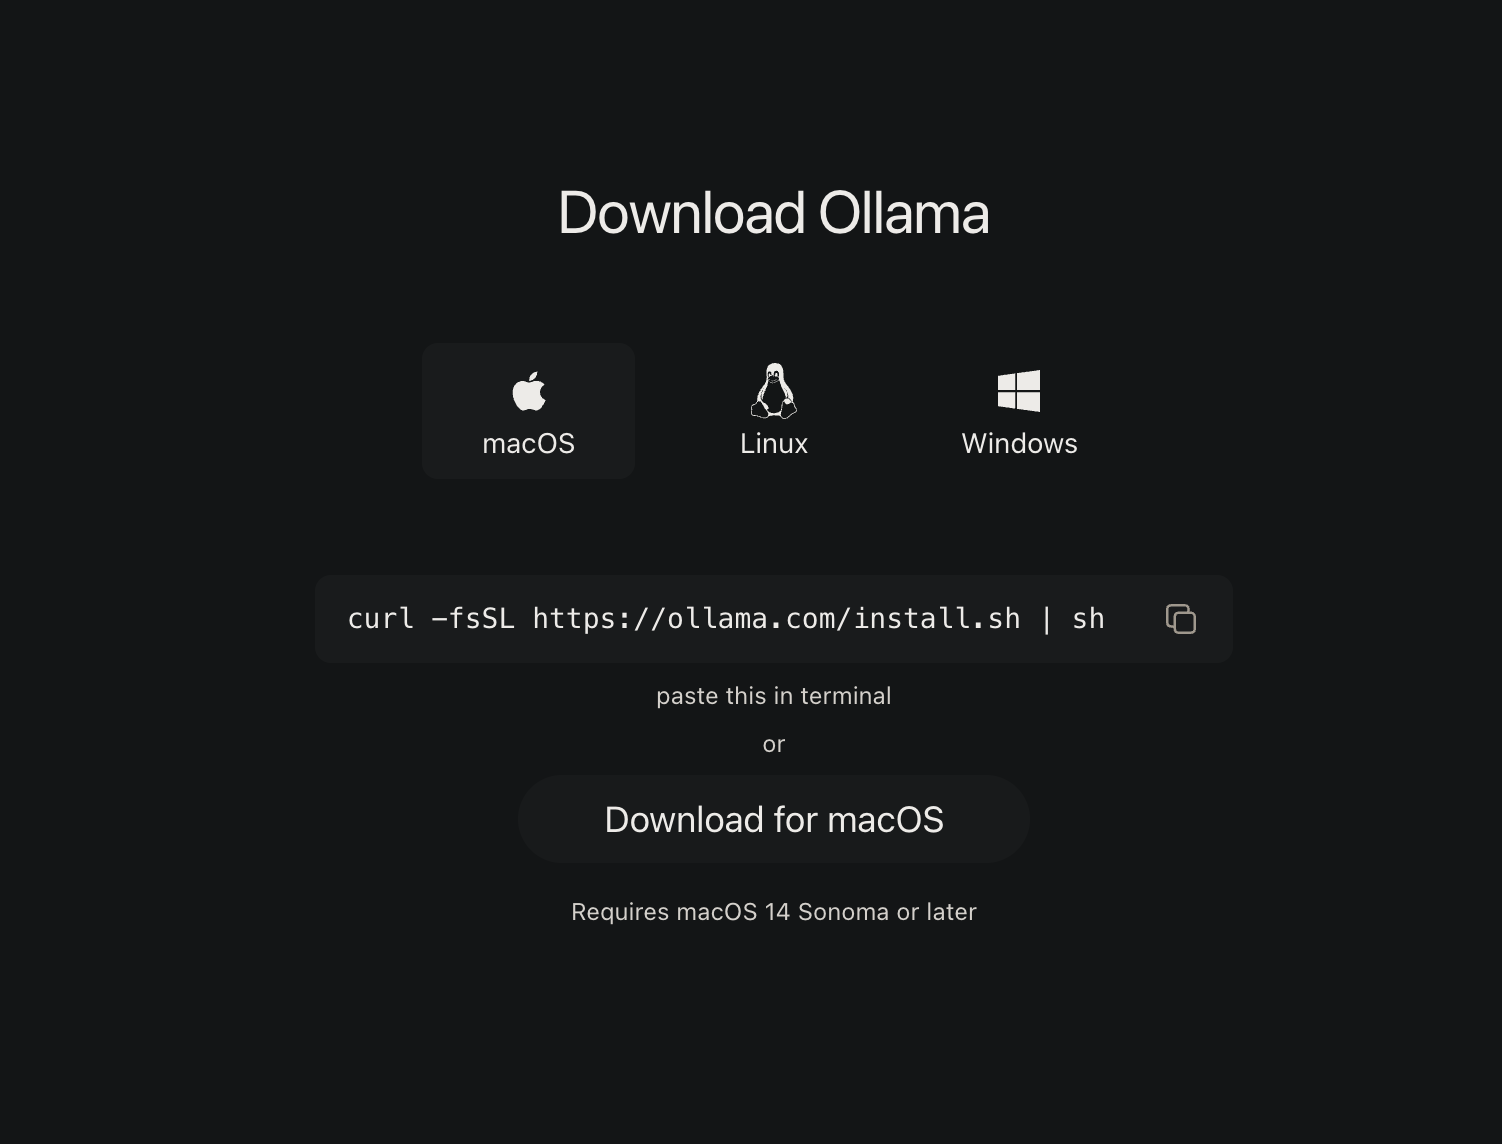

### （2）安装

- 按照提示，安装即可

### （3）使用-命令行

ollama pull qwen3.5 8b    #下载模型

In [33]:
!ollama -h #帮助

]11;?\Large language model runner

Usage:
  ollama [flags]
  ollama [command]

Available Commands:
  serve       Start Ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch the Ollama menu or an integration
  help        Help about any command

Flags:
  -h, --help         help for ollama
      --nowordwrap   Don't wrap words to the next line automatically
      --verbose      Show timings for response
  -v, --version      Show version information

Use "ollama [command] --help" for more information about a command.


In [34]:
! ollama ps #查看当前运行的model

]11;?\NAME    ID    SIZE    PROCESSOR    CONTEXT    UNTIL 


In [11]:
!ollama --help

]11;?\Large language model runner

Usage:
  ollama [flags]
  ollama [command]

Available Commands:
  serve       Start Ollama
  create      Create a model
  show        Show information for a model
  run         Run a model
  stop        Stop a running model
  pull        Pull a model from a registry
  push        Push a model to a registry
  signin      Sign in to ollama.com
  signout     Sign out from ollama.com
  list        List models
  ps          List running models
  cp          Copy a model
  rm          Remove a model
  launch      Launch the Ollama menu or an integration
  help        Help about any command

Flags:
  -h, --help         help for ollama
      --nowordwrap   Don't wrap words to the next line automatically
      --verbose      Show timings for response
  -v, --version      Show version information

Use "ollama [command] --help" for more information about a command.


In [36]:
!ollama list

]11;?\NAME                     ID              SIZE      MODIFIED       
llama3.2:3b              a80c4f17acd5    2.0 GB    24 minutes ago    
deepseek-ocr:3b          0e7b018b8a22    6.7 GB    32 minutes ago    
qwen3-vl:4b              1343d82ebee3    3.3 GB    39 minutes ago    
deepseek-coder-v2:16b    63fb193b3a9b    8.9 GB    43 minutes ago    
qwen3.5:9b               6488c96fa5fa    6.6 GB    3 hours ago       
deepseek-r1:1.5b         e0979632db5a    1.1 GB    20 hours ago      


In [ ]:
! ollama show deepseek-ocr:3b

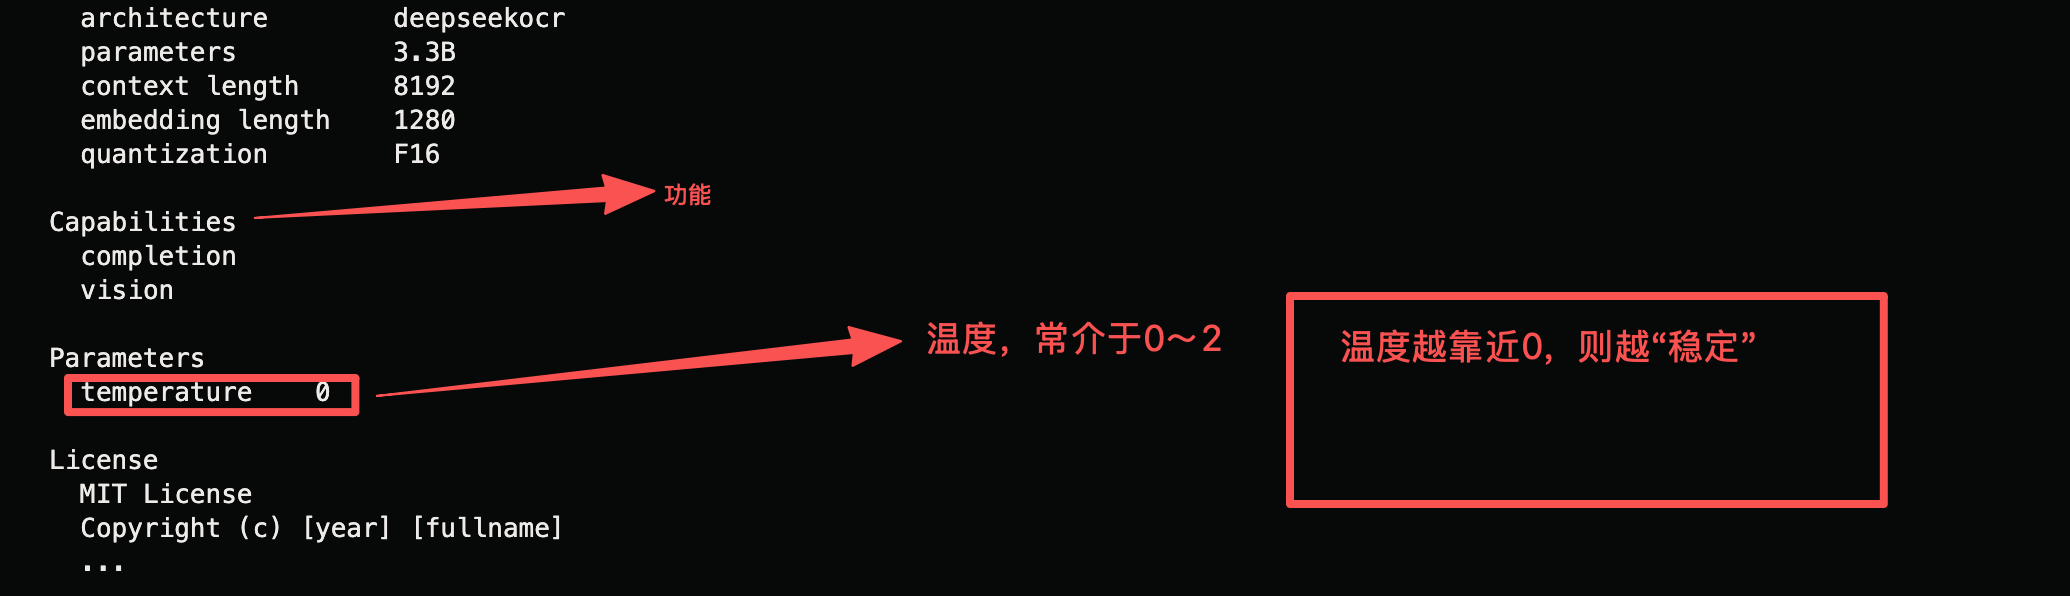

## 1.2 下载模型

 - 支持ollama的模型必须使用独有的格式- GUFF
    - 其他的模型safetensor必须转换为GUFF

- 下载方式有两种：
    - 使用ollama （推荐）
        -图形界面
        - 指令下载
    - 使用git 下载（下载工具下载）

## 1.3 使用大模型服务

### (1) 调用的endpoints

- http://localhost:11434/api/generate
     - 服务发布使用的是http协议

- 端口的设置：
    - 默认的端口

In [17]:
!ollama serve -h

]11;?\Start Ollama

Usage:
  ollama serve [flags]

Aliases:
  serve, start

Flags:
  -h, --help   help for serve

Environment Variables:
      OLLAMA_DEBUG               Show additional debug information (e.g. OLLAMA_DEBUG=1)
      OLLAMA_HOST                IP Address for the ollama server (default 127.0.0.1:11434)
      OLLAMA_CONTEXT_LENGTH      Context length to use unless otherwise specified (default: 4k/32k/256k based on VRAM)
      OLLAMA_KEEP_ALIVE          The duration that models stay loaded in memory (default "5m")
      OLLAMA_MAX_LOADED_MODELS   Maximum number of loaded models per GPU
      OLLAMA_MAX_QUEUE           Maximum number of queued requests
      OLLAMA_MODELS              The path to the models directory
      OLLAMA_NUM_PARALLEL        Maximum number of parallel requests
      OLLAMA_NO_CLOUD            Disable Ollama cloud features (remote inference and web search)
      OLLAMA_NOPRUNE             Do not prune model blobs on startup
      OLLAMA_ORIGINS     

- 调用方式：
    - ollama应用：ollama app
    - ollama run "模型" "提示词"
    - 第三方http工具：curl
    - 使用python的http模块：request
    - 使用ollama提供的框架：ollama
    - 使用langchain的扩展工具
    - **使用langchain统一的服务接口**

### (2）使用curl调用

- 该工具简单粗暴，仅仅用来测试

In [19]:
!curl http://localhost:11434/api/tags

{"models":[{"name":"qwen3.5:9b","model":"qwen3.5:9b","modified_at":"2026-04-07T10:29:01.246299018+08:00","size":6594474711,"digest":"6488c96fa5faab64bb65cbd30d4289e20e6130ef535a93ef9a49f42eda893ea7","details":{"parent_model":"","format":"gguf","family":"qwen35","families":["qwen35"],"parameter_size":"9.7B","quantization_level":"Q4_K_M"}},{"name":"deepseek-r1:1.5b","model":"deepseek-r1:1.5b","modified_at":"2026-04-06T17:22:22.905976881+08:00","size":1117322768,"digest":"e0979632db5a88d1a53884cb2a941772d10ff5d055aabaa6801c4e36f3a6c2d7","details":{"parent_model":"","format":"gguf","family":"qwen2","families":["qwen2"],"parameter_size":"1.8B","quantization_level":"Q4_K_M"}}]}

In [24]:
!curl http://localhost:11434/api/generate -d '{"model": "qwen3.5:9b", "prompt": "3+2等于？", "stream": false}'

{"model":"qwen3.5:9b","created_at":"2026-04-07T03:31:54.974132Z","response":"3+2 等于 5。","thinking":"Thinking Process:\n\n1.  **Analyze the Request:** The user is asking a simple arithmetic question: \"3+2 等于？\" (What does 3+2 equal?).\n\n2.  **Calculate the Answer:** 3 + 2 = 5.\n\n3.  **Formulate the Response:** The answer should be direct and clear.\n    *   Language: Chinese (matching the query).\n    *   Content: \"5\".\n\n4.  **Final Output Construction:** \"3+2 等于 5。\" or simply \"5\". A complete sentence is usually better for politeness and clarity.\n\n5.  **Review:** Is there any trick? No. Is it a riddle? No. Just basic math.\n\n6.  **Final Decision:** Output \"5\". Or \"3+2 等于 5。\" Let's go with the complete sentence for clarity.\n\n    *   Draft: 3+2 等于 5。\n    *   Refinement: Keep it simple.\n\n    Output: 5","done":true,"done_reason":"stop","context":[248045,846,198,18,10,17,102149,10992,248046,198,248045,74455,198,248068,198,90700,8340,25,271,16,13,220,2972,2014,53983,279,

### (3）使用request调用

In [29]:
import requests
import json

# 发起一个请求
response = requests.post(
    "http://localhost:11434/api/chat",
    json={
        "model": "qwen3.5:9b",
        "messages": [
            {
                "role": "system",  # 只写一次
                "content": "你是一个算术大师，请使用简洁精准的方式给出答案"
            },
            {
                "role": "user",
                "content": "99 * 2099=?"
            }
        ],
        "stream": False  # 关闭流式输出，一次性返回完整结果
    }
)

# 解析请求结果
respoense.encoding="utf-8"  #解决编码问题
print(response.json()["message"]["content"])

207801


### (4）使用ollama 框架调用

In [1]:
import ollama
help(ollama.generate)

Help on method generate in module ollama._client:

generate(
    model: str = '',
    prompt: Optional[str] = None,
    suffix: Optional[str] = None,
    *,
    system: Optional[str] = None,
    template: Optional[str] = None,
    context: Optional[Sequence[int]] = None,
    stream: bool = False,
    think: Optional[bool] = None,
    logprobs: Optional[bool] = None,
    top_logprobs: Optional[int] = None,
    raw: Optional[bool] = None,
    format: Union[Literal['', 'json'], dict[str, Any], NoneType] = None,
    images: Optional[Sequence[Union[str, bytes, ollama._types.Image]]] = None,
    options: Union[Mapping[str, Any], ollama._types.Options, NoneType] = None,
    keep_alive: Union[float, str, NoneType] = None
) -> Union[ollama._types.GenerateResponse, collections.abc.Iterator[ollama._types.GenerateResponse]] method of ollama._client.Client instance
    Create a response using the requested model.

    Raises `RequestError` if a model is not provided.

    Raises `ResponseError` if 

In [2]:
help(ollama.chat)

Help on method chat in module ollama._client:

chat(
    model: str = '',
    messages: Optional[Sequence[Union[Mapping[str, Any], ollama._types.Message]]] = None,
    *,
    tools: Optional[Sequence[Union[Mapping[str, Any], ollama._types.Tool, Callable]]] = None,
    stream: bool = False,
    think: Union[bool, Literal['low', 'medium', 'high'], NoneType] = None,
    logprobs: Optional[bool] = None,
    top_logprobs: Optional[int] = None,
    format: Union[Literal['', 'json'], dict[str, Any], NoneType] = None,
    options: Union[Mapping[str, Any], ollama._types.Options, NoneType] = None,
    keep_alive: Union[float, str, NoneType] = None
) -> Union[ollama._types.ChatResponse, collections.abc.Iterator[ollama._types.ChatResponse]] method of ollama._client.Client instance
    Create a chat response using the requested model.

    Args:
      tools:
        A JSON schema as a dict, an Ollama Tool or a Python Function.
        Python functions need to follow Google style docstrings to be co

- ollama 调用主要实现
    - client 
        - 返回一堆响应：对应不同的Endpoint
        - 使用工厂函数 ，直接创建client

In [ ]:
import ollama

#ollama.list()
resulut = ollama.generate(
    model="qwen3.5:0.8b", 
    prompt="写一首西湖的七言律诗",
    think=False
    )

#print(type(resulut))
#print(resulut["response"])

<class 'ollama._types.GenerateResponse'>
**《西湖晚望》**

苏堤春晓柳丝长，十里荷花满碧塘。
山色空蒙含雨气，塔光摇曳倚斜阳。
画船载酒穿烟水，野鹤鸣松落翠苍。
最爱湖山归去好，此身已在画图行。

---

**【赏析】**
这首诗试图捕捉西湖不同季节与时间的经典美景。首联以“苏堤”和“荷花”点出西湖最具代表性的景物，一写早春之柳，一写盛夏之荷（虽题为晚望，意象可通感四季，或特指盛夏暮色）。颔联描写雨后山峦的空蒙之感与雷峰塔（或保俶塔）在夕阳下的倒影，营造朦胧意境。颈联转入动态，描绘画船穿行烟波、野鹤归林的闲适画面。尾联抒发对西湖山水的眷恋，表达沉醉其中、恍若置身画卷的陶醉之情。全诗严格遵循七言律诗的平仄与对仗要求。


In [2]:
import ollama

#ollama.list()
resulut = ollama.generate(
    model="qwen3.5:0.8b", 
    prompt="写一首西湖的七言律诗",
    think=False,
    stream=True
    )
# 流式输出时，resulut是一个生成器对象，可以逐步获取模型的输出
for chunk in resulut:
    print(chunk["response"], end="",flush=True)

**《西湖暮雨》**

**烟雨千峰翠欲秋，**
**危楼极目入神州。**
**断桥残照惊飞鸟，**
**残照残波送晚舟。**
**一洗尘心消客恨，**
**万条杨柳接长流。**
**不知此日西湖好，**
**梦里江山又画愁。**

### (5）使用langchain调用

In [5]:
!pip3 install langchain_ollama

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.7/604.7 kB 480.3 kB/s  0:00:01623.7 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 640.4/640.4 kB 653.3 kB/s  0:00:01773.4 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10/10 [langchain_ollama]2m 8/10 [langchain-core]


- 大模型的服务本质：
    - HTTP协议的web Servie.
         - 调用的核心是 http的请求与响应； 调用方法很多

         - langchain,封装所有的大模型(lanagchain对每个大模型的服务供应商提供扩展，可以理解为：在langchain不关注每个厂商的服务差异)：
               -  每个厂商URL不一样
               -  实际上每个厂商提供自己的API
         - langchain 对每个厂商使用transformers 的每个厂商进行统一规范
                 - ip : port

In [5]:
from langchain_ollama import OllamaLLM

llm = OllamaLLM(
    model="qwen3.5:0.8b",
    temperature=0.7,
    num_predict=2048,
    base_url="http://localhost:11434",
    stream=False
)

# 测试连接
try:
    response = llm.invoke("使用c++，写一个冒泡排序算法")
    print(response)
    print("返回类型：", type(response))  # 正常是 str 字符串
except Exception as e:
    print("错误：", e)

# C++ 冒泡排序实现

以下是使用 C++ 编写的冒泡排序算法实现，包含三种版本，并附带详细的注释和测试示例。

## 1. 基本实现（原地排序）

```cpp
#include <iostream>
#include <vector>

using namespace std;

// 冒泡排序算法
void bubbleSort(vector<int>& arr) {
    int n = arr.size();
    for (int i = 0; i < n; i++) {
        for (int j = 0; j < n - 1 - i; j++) {
            if (arr[j] > arr[j + 1]) {
                // 交换
                swap(arr[j], arr[j + 1]);
            }
        }
        // 交换后元素
        if (i < n - 1) {
            bool swapped = false;
            for (int j = 0; j < n - 1 - i; j++) {
                if (arr[j] > arr[j + 1]) {
                    swap(arr[j], arr[j + 1]);
                    swapped = true;
                }
            }
            if (!swapped) break;
        }
    }
}

// 辅助函数：交换两个元素
void swap(vector<int>& arr, int i, int j) {
    if (i != j) {
        int temp = arr[i];
        arr[i] = arr[j];
        arr[j] = temp;
    }
}

// 辅助函数：比较两个元素是否相等
bool isEqual(vector<int>& arr, int i, int j) {
    return arr[i

### (6) 使用统一的接口 调用大模型服务

In [9]:
! pip3 install langchain  

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [langchain]/6 [langchain]


In [13]:
from langchain.chat_models import init_chat_model           #

model = init_chat_model(
    model="qwen3.5:0.8b",
    model_provider="ollama",
    temperature=0.7,
    num_predict=2048,
    base_url="http://localhost:11434",
    stream=False        #是否启用流式输出           
)

print(type(model))

#调用

response = model.invoke("使用java，写一个冒泡排序算法;")
print(response.content)

<class 'langchain_ollama.chat_models.ChatOllama'>
以下是一个使用 Java 实现的冒泡排序算法，包含完整的实现逻辑和多种实现方式，便于理解与使用。

## 一、算法说明

冒泡排序是一种稳定排序算法，通过逐步比较相邻元素并交换，直到整个数组达到有序状态。其核心思想是：

1. 每次从数组中比较相邻元素；
2. 如果当前元素比后一个元素大（即不满足升序），则交换；
3. 重复此过程，直到数组中最大的元素已经排到末尾；
4. 若数组为空，则直接返回。

## 二、基本实现（使用辅助方法）

```java
public class BubbleSort {
    public static void bubbleSort(int[] arr) {
        int n = arr.length;
        for (int i = 0; i < n; i++) {
            boolean swapped = false;
            for (int j = 0; j < n - i - 1; j++) {
                if (arr[j] > arr[j + 1]) {
                    int temp = arr[j];
                    arr[j] = arr[j + 1];
                    arr[j + 1] = temp;
                    swapped = true;
                }
            }
            if (!swapped) break;
        }
    }

    public static void main(String[] args) {
        int[] arr = {64, 34, 25, 12, 22, 11, 90};
        bubbleSort(arr);
        System.out.println(Arrays.toString(arr));
    }
}
```

## 三、使用辅助方法实现（更简洁）

```java
publ